In [1]:
import joblib
import cloudpickle
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

import pymc as pm
import arviz as az
import arviz_plots as azp
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Arc

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', None)

In [2]:
print(pm.__version__)

5.25.1


In [3]:
bart_mm_scaler = joblib.load('minmax_scaler.pkl')

In [4]:
df=pd.read_csv('input/full_results.csv')
df['shot_type_idx'] = df['shot_type'].map({'JUMPER': 0, 'LAYUP': 1, 'HOOK': 2, 'DUNK': 3})
df['sub_type_idx'] = df['subType_idx'] - 1
df['season_idx'] = df['season_idx'] - 1
df = df.loc[df['period']<=4].reset_index(drop=True)
df['PLAYER_ID'] = pd.to_numeric(df['PLAYER_ID'], errors='coerce')
df = df.dropna(subset=['PLAYER_ID'])
df.head()

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train,distance_mm,angle_mm,probs,baseline_logit,logit_sd,sub_type_idx
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,0,2022-23,0,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1,0.267300,0.670484,0.428531,-0.288581,0.103031,0
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,0,2022-23,0,Marcus Smart,203935.0,29.401780,76.0,G,2,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1,0.275325,0.653883,0.427449,-0.292989,0.101178,1
2,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,1,2022-23,0,Tobias Harris,202699.0,31.041752,79.0,F,3,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1,0.000000,0.000000,0.697259,0.841187,0.188602,3
3,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,0,2022-23,0,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1,0.494566,0.780882,0.384304,-0.472442,0.098655,4
4,22200001,6,17,23,MISS Maxey 4' Driving Layup,0,3.883298,78.111342,38,8,2,Driving Layup Shot,6,LAYUP,1,2022-23,0,Tyrese Maxey,1630178.0,22.735113,74.0,G,2,1.610613e+09,BOS,1,1.610613e+09,PHI,1.610613e+09,BOS,1,2.0,5.0,-3.0,1,10.200000,612.0,0,1610612755,PHI,1,0.080995,0.781255,0.487208,-0.051393,0.135053,5


In [5]:
from typing import Union
def define_index(data: pd.DataFrame, label: str) -> Union[np.array, dict]:
    """Defines an index variable starting at 1. We add 1 so '0' can act as a placeholder for
    any global optionality
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    data[label] = data[label].apply(str)
    unq_ids = data[label].unique()
    n_ids = len(unq_ids)
    lookup_dict = dict(zip(unq_ids, range(n_ids)))
    return data[label].replace(lookup_dict).values + 1, lookup_dict

In [6]:
df["player_idx"], player_lookup = define_index(df, "PLAYER_ID")
# provide an index for teamID
df["team_idx"], team_lookup = define_index(df, "teamId")
# provide an index for hometeamID (court factor)
df["court_idx"], hometeam_lookup = define_index(df, "homeTeamId")
# positin
df["position_idx"], position_lookup = define_index(df, "POSITION")
# team defense
df["def_idx"], def_team_lookup = define_index(df, "defTeamId")

df.head()

/tmp/ipykernel_9363/2469266612.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data[label].replace(lookup_dict).values + 1, lookup_dict
/tmp/ipykernel_9363/2469266612.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return data[label].replace(lookup_dict).values + 1, lookup_dict
/tmp/ipykernel_9363/2469266612.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

,gameId,event_id,actionId,actionNumber,description,is_made,SHOT_DISTANCE,ANGLE,xLegacy,yLegacy,shotValue,subType,subType_idx,shot_type,shot_type_idx,SEASON,season_idx,PLAYER,PLAYER_ID,player_age,HEIGHT_INCHES,POSITION,position_idx,homeTeamId,homeTeamTricode,court_idx,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,def_idx,score_shooter,score_opposition,score_diff,period,time_minutes,time_seconds,ishome_shooter,teamId,teamTricode,is_train,distance_mm,angle_mm,probs,baseline_logit,logit_sd,sub_type_idx,player_idx,team_idx
0,22200001,0,3,7,MISS Embiid 13' Turnaround Fadeaway Shot,0,12.815615,67.036227,-118,50,2,Turnaround Fadeaway shot,1,JUMPER,0,2022-23,0,Joel Embiid,203954.0,29.374401,84.0,C-F,1,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,0.0,0.0,0.0,1,11.633333,698.0,0,1610612755,PHI,1,0.267300,0.670484,0.428531,-0.288581,0.103031,0,1,1
1,22200001,1,7,11,Smart 13' Driving Floating Bank Jump Shot (2 PTS),1,13.200379,65.376435,120,55,2,Driving Floating Bank Jump Shot,2,JUMPER,0,2022-23,0,Marcus Smart,203935.0,29.401780,76.0,G,2,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,2.0,0.0,2.0,1,11.250000,675.0,1,1610612738,BOS,1,0.275325,0.653883,0.427449,-0.292989,0.101178,1,2,2
2,22200001,3,10,14,Harris Tip Layup Shot (2 PTS),1,0.000000,0.000000,0,0,2,Tip Layup Shot,4,LAYUP,1,2022-23,0,Tobias Harris,202699.0,31.041752,79.0,F,3,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,2.0,2.0,0.0,1,11.050000,663.0,0,1610612755,PHI,1,0.000000,0.000000,0.697259,0.841187,0.188602,3,3,1
3,22200001,4,11,15,Tatum 24' 3PT Jump Shot (3 PTS) (Smart 1 AST),1,23.711811,78.074008,-232,49,3,Jump Shot,5,JUMPER,0,2022-23,0,Jayson Tatum,1628369.0,25.409993,80.0,F-G,4,1610612738.0,BOS,1,1.610613e+09,PHI,1610612755.0,PHI,2,5.0,2.0,3.0,1,10.766667,646.0,1,1610612738,BOS,1,0.494566,0.780882,0.384304,-0.472442,0.098655,4,4,2
4,22200001,6,17,23,MISS Maxey 4' Driving Layup,0,3.883298,78.111342,38,8,2,Driving Layup Shot,6,LAYUP,1,2022-23,0,Tyrese Maxey,1630178.0,22.735113,74.0,G,2,1610612738.0,BOS,1,1.610613e+09,PHI,1610612738.0,BOS,1,2.0,5.0,-3.0,1,10.200000,612.0,0,1610612755,PHI,1,0.080995,0.781255,0.487208,-0.051393,0.135053,5,5,1


In [7]:
target=df['is_made'].values
df.shape

(497034, 49)

In [8]:
def sample(
    model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED
):
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            cores=4,
            idata_kwargs={"log_likelihood": False}
        )
    return trace

def compute_log_likelihood(model: pm.Model, trace: az.InferenceData) -> None:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: az.InferenceData) -> az.InferenceData:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (az.InferenceData): Results from sampling

    Returns:
        az.InferenceData: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [9]:
shot_type_idx_vals = df['shot_type_idx'].values
player_idx_vals = df['player_idx'].values
season_idx_vals = df['season_idx'].values
baseline_logit_vals = df['baseline_logit'].values

In [10]:
coords = {
    "obs_id": np.arange(len(target)),
    "shot_type":["JUMPER", "LAYUP", "HOOK", "DUNK"],
    "player": ["Average"]+pd.unique(df['PLAYER']).tolist(),
    "season" : ['2022/2023','2023/2024','2024/2025']
    }
with pm.Model(coords=coords) as model:
    # mutable data
    shot_made = pm.Data("shot_made", target, dims=("obs_id",))
    baseline_logits = pm.Data("baseline_logits", baseline_logit_vals, dims=("obs_id",))
    shot_type_idx = pm.Data("shot_type_idx", shot_type_idx_vals.astype("int32"), dims=("obs_id",))
    player_idx = pm.Data("player_idx", player_idx_vals.astype("int32"), dims=("obs_id",))
    season_idx = pm.Data("season_idx", season_idx_vals.astype("int32"), dims=("obs_id",))
    
    # baseline
    baseline_weight = pm.Normal("baseline_weight", 1, 0.25)
    
    # shot type effect
    sigma_shot_type = pm.HalfNormal("sigma_shot_type", 1.0)
    shot_type_effect = pm.Normal("shot_type_effect", mu=0.0, sigma=sigma_shot_type, dims=("shot_type",))
    shot_type_contribution = shot_type_effect[shot_type_idx]
    
    # player effect
    sigma_player = pm.HalfNormal("sigma_player", 1.0, dims=("shot_type",))
    player_offset = pm.Normal(
        "player_offset", mu=0.0, sigma=1.0,
        dims=("player", "season", "shot_type")
    )
    player_centered = player_offset - player_offset.mean(axis=0, keepdims=True)
    player_effect = pm.Deterministic(
        "player_effect",
        player_centered * sigma_player[None, None, :],
        dims=("player", "season", "shot_type")
    )
    player_contribution = player_effect[player_idx, season_idx, shot_type_idx]
    
    # additive components
    theta = baseline_weight*baseline_logits + shot_type_contribution + player_contribution
    shot_lkhood = pm.Bernoulli("shot_lkhood", logit_p=theta, observed=shot_made, dims=("obs_id",))

In [11]:
trace = sample(model, tune=1500, draws=1500, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [baseline_weight, sigma_shot_type, shot_type_effect, sigma_player, player_offset]


Output()

Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 4810 seconds.


In [12]:
az.to_netcdf(trace, 'trace_objects/player.nc')

'trace_objects/player.nc'

In [13]:
with open("models_pkl/player.pkl", "wb") as f:
    cloudpickle.dump(model, f)

In [14]:
az.summary(
    trace,
    var_names=["player_effect"],
    filter_vars="like"
).filter(like="Stephen Curry", axis=0)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"player_effect[Stephen Curry, 2022/2023, JUMPER]",0.251,0.067,0.129,0.382,0.001,0.001,6771.0,4370.0,1.0
"player_effect[Stephen Curry, 2022/2023, LAYUP]",0.462,0.113,0.256,0.673,0.001,0.002,7322.0,4943.0,1.0
"player_effect[Stephen Curry, 2022/2023, HOOK]",0.054,0.291,-0.461,0.624,0.004,0.004,5941.0,4608.0,1.0
"player_effect[Stephen Curry, 2022/2023, DUNK]",0.002,0.387,-0.727,0.746,0.005,0.006,6792.0,4502.0,1.0
"player_effect[Stephen Curry, 2023/2024, JUMPER]",0.154,0.062,0.035,0.267,0.001,0.001,6186.0,4459.0,1.0
"player_effect[Stephen Curry, 2023/2024, LAYUP]",0.413,0.124,0.185,0.645,0.001,0.002,7452.0,4691.0,1.0
"player_effect[Stephen Curry, 2023/2024, HOOK]",-0.016,0.289,-0.587,0.507,0.003,0.004,7293.0,4564.0,1.0
"player_effect[Stephen Curry, 2023/2024, DUNK]",-0.009,0.369,-0.739,0.638,0.004,0.005,6912.0,4632.0,1.0
"player_effect[Stephen Curry, 2024/2025, JUMPER]",0.197,0.064,0.075,0.316,0.001,0.001,7826.0,4136.0,1.0
"player_effect[Stephen Curry, 2024/2025, LAYUP]",0.224,0.121,-0.005,0.445,0.001,0.002,7323.0,4295.0,1.0


In [15]:
az.summary(
    trace,
    var_names=[
        "baseline_weight",
        "sigma_shot_type",
        "shot_type_effect",
        "sigma_player"
        ]
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
baseline_weight,1.064,0.010,1.044,1.083,0.000,0.000,3230.0,3976.0,1.0
sigma_shot_type,0.795,0.303,0.341,1.345,0.004,0.006,5954.0,3992.0,1.0
shot_type_effect[JUMPER],0.001,0.007,-0.012,0.013,0.000,0.000,2379.0,3600.0,1.0
shot_type_effect[LAYUP],-0.236,0.009,-0.254,-0.220,0.000,0.000,3147.0,4171.0,1.0
shot_type_effect[HOOK],-0.074,0.024,-0.119,-0.030,0.000,0.000,3102.0,3728.0,1.0
shot_type_effect[DUNK],1.259,0.024,1.215,1.305,0.000,0.000,3920.0,4249.0,1.0
sigma_player[JUMPER],0.133,0.006,0.122,0.144,0.000,0.000,2229.0,3708.0,1.0
sigma_player[LAYUP],0.225,0.009,0.209,0.242,0.000,0.000,2598.0,3976.0,1.0
sigma_player[HOOK],0.302,0.028,0.251,0.357,0.001,0.000,1696.0,3311.0,1.0
sigma_player[DUNK],0.381,0.031,0.326,0.441,0.001,0.000,2243.0,3304.0,1.0


In [16]:
compute_log_likelihood(model, trace)

Output()

In [17]:
az.loo(trace, var_name='shot_lkhood')

Computed from 6000 posterior samples and 497034 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -320288.80   203.52
p_loo     1600.42        -
------

Pareto k diagnostic values:
                          Count   Pct.
(-Inf, 0.70]   (good)     497034  100.0%
   (0.70, 1]   (bad)           0    0.0%
   (1, Inf)   (very bad)      0    0.0%

In [18]:
spp = sample_posterior_pred(model, trace)

Sampling: [shot_lkhood]


Output()

<Axes: xlabel='shot_lkhood'>

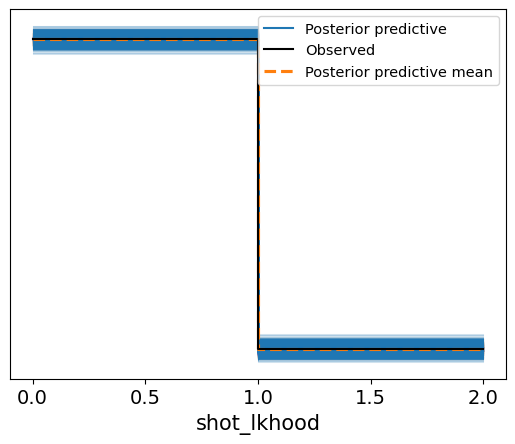

In [19]:
az.plot_ppc(spp, var_names='shot_lkhood', num_pp_samples=1000,random_seed=RANDOM_SEED)

In [20]:
del spp

<Axes: >

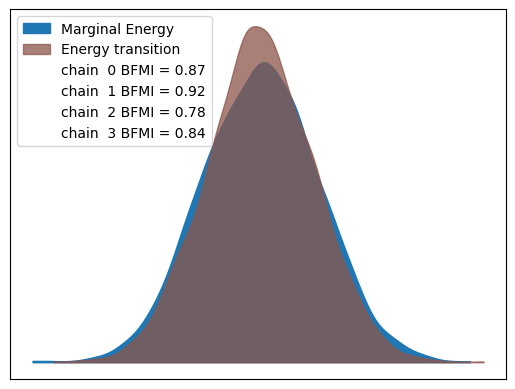

In [21]:
az.plot_energy(trace)

In [22]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

In [23]:
from scipy.special import expit
from tqdm import tqdm
baseline_weight  = trace.posterior["baseline_weight"].values
shot_type_effect = trace.posterior["shot_type_effect"].values
player_effect = trace.posterior["player_effect"].values

shot_type_contribution = shot_type_effect[:, :, shot_type_idx_vals]
player_contribution = player_effect[:,:,player_idx_vals, season_idx_vals, shot_type_idx_vals]

In [24]:
def compute_theta(baseline_weight, shot_type_contribution, player_contribution, batch_size=5000):
    n_obs = shot_type_contribution.shape[2]
    batches = np.arange(0, n_obs, batch_size)

    logits_mean_list = []
    logits_sd_list = []
    probs_mean_list  = []

    for start in tqdm(batches):
        end = min(start + batch_size, n_obs)
        baseline_logit_batch = baseline_weight[:, :, None] * baseline_logit_vals[None, None, start:end]
        shot_type_contra_batch = shot_type_contribution[:, :, start:end]
        player_contra_batch = player_contribution[:, :, start:end]
        
        logits = baseline_logit_batch + shot_type_contra_batch + player_contra_batch
        probs = expit(logits)
        logits_mean = logits.mean(axis=(0, 1))
        logits_mean_list.append(logits_mean)
        probs_mean_list.append(probs.mean(axis=(0, 1)))
        logits_sd_list.append(logits.std(axis=(0, 1)))

        del logits, probs, baseline_logit_batch, shot_type_contra_batch, player_contra_batch

    return {
        "logits":     np.concatenate(logits_mean_list),
        "probs":      np.concatenate(probs_mean_list),
        "logits_sd":  np.concatenate(logits_sd_list)
    }

In [25]:
results = compute_theta(
    baseline_weight,
    shot_type_contribution,
    player_contribution
    )

100%|██████████| 100/100 [00:36<00:00,  2.74it/s]


In [26]:
results["logits"]

array([-0.10603982, -0.36517668,  0.67794812, ..., -0.48496524,
       -0.54336166, -0.20956576], shape=(497034,))

In [27]:
results["probs"].min()

np.float64(0.2356437293670256)

In [28]:
train_score = compute_scores(target, results['probs'])
print("Train Log Loss:", train_score[0])
print("Train AUC:", train_score[1])
print("Train Accuracy:", train_score[2])

Train Log Loss: 0.641180249989321
Train AUC: 0.6581768409255273
Train Accuracy: 0.6266392238760327
